#ASSIGNMENT 5
#Exploring the Latent Space of a Pretrained StyleGAN2 Model


Enabling GPU


In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


#1. Import Libraries

In [ ]:
!pip install -q ninja

!git clone https://github.com/NVlabs/stylegan2-ada-pytorch.git

%cd stylegan2-ada-pytorch

fatal: destination path 'stylegan2-ada-pytorch' already exists and is not an empty directory.
/content/stylegan2-ada-pytorch


In [ ]:
!wget -q https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada-pytorch/pretrained/ffhq.pkl

import os

print("Model exists:", os.path.exists("ffhq.pkl"))

Model exists: True


In [ ]:
#loading the generator

import pickle
import torch

with open("ffhq.pkl", "rb") as f:
    G = pickle.load(f)["G_ema"].to(device)

G.eval()

print("StyleGAN2 generator loaded successfully!")

StyleGAN2 generator loaded successfully!


#2. Generation of Random Latent Vectors

In [ ]:
# Latent dimension of StyleGAN2
z_dim = 512

# Generate two random latent vectors
Z1 = torch.randn(1, z_dim, device=device)
Z2 = torch.randn(1, z_dim, device=device)

print("Z1 shape:", Z1.shape)
print("Z2 shape:", Z2.shape)

Z1 shape: torch.Size([1, 512])
Z2 shape: torch.Size([1, 512])


In [ ]:
import torch
import sys

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
PyTorch: 2.6.0+cu124
CUDA available: True
CUDA version: 12.4


In [ ]:
!pip uninstall -y torch torchvision torchaudio
!pip install -q torch==2.6.0 torchvision==0.21.0 torchaudio==2.6.0

Found existing installation: torch 2.6.0
Uninstalling torch-2.6.0:
  Successfully uninstalled torch-2.6.0
Found existing installation: torchvision 0.21.0
Uninstalling torchvision-0.21.0:
  Successfully uninstalled torchvision-0.21.0
Found existing installation: torchaudio 2.6.0
Uninstalling torchaudio-2.6.0:
  Successfully uninstalled torchaudio-2.6.0


In [ ]:
import torch
import sys

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
PyTorch: 2.6.0+cu124
CUDA available: True
CUDA version: 12.4


#3. Generate two images using vectors Z1 and Z2

In [ ]:
import torch
import pickle

# Load pretrained generator
with open("ffhq.pkl", "rb") as f:
    G = pickle.load(f)["G_ema"].to(device)

G.eval()

print("Generator loaded successfully!")

Generator loaded successfully!


In [ ]:
# Generate images from Z1 and Z2
with torch.no_grad():
    img1 = G(Z1, None, noise_mode='const', force_fp32=True)
    img2 = G(Z2, None, noise_mode='const', force_fp32=True)

print("Image 1 shape:", img1.shape)
print("Image 2 shape:", img2.shape)

Setting up PyTorch plugin "bias_act_plugin"... 

/usr/local/lib/python3.13/dist-packages/torch/utils/cpp_extension.py:2059: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(


Done.
Setting up PyTorch plugin "upfirdn2d_plugin"... 

/usr/local/lib/python3.13/dist-packages/torch/utils/cpp_extension.py:2059: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(


Done.
Image 1 shape: torch.Size([1, 3, 1024, 1024])
Image 2 shape: torch.Size([1, 3, 1024, 1024])


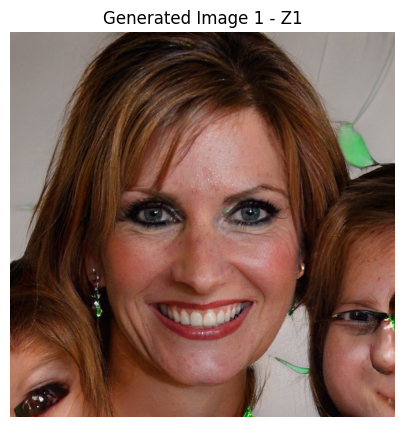

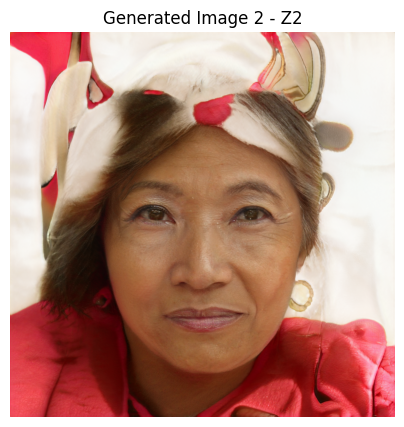

In [ ]:
import matplotlib.pyplot as plt

def show_image(img, title):
    img = (img[0].permute(1, 2, 0) + 1) / 2
    img = img.clamp(0, 1)

    plt.figure(figsize=(5, 5))
    plt.imshow(img.cpu())
    plt.axis("off")
    plt.title(title)
    plt.show()

show_image(img1, "Generated Image 1 - Z1")
show_image(img2, "Generated Image 2 - Z2")

In [ ]:
from PIL import Image
import numpy as np

def save_image(img, filename):
    img = (img[0].permute(1, 2, 0) + 1) / 2
    img = img.clamp(0, 1)
    img = (img.cpu().numpy() * 255).astype(np.uint8)

    Image.fromarray(img).save(filename)

save_image(img1, "image_1_Z1.png")
save_image(img2, "image_2_Z2.png")

print("Initial images saved successfully.")

Initial images saved successfully.


#4. Linear Interpolation b/w Z1 and Z2


In [ ]:
import torch
import matplotlib.pyplot as plt


num_steps = 12

alphas = torch.linspace(0, 1, num_steps, device=device)

interpolated_Z = []

for alpha in alphas:
    z = (1 - alpha) * Z1 + alpha * Z2
    interpolated_Z.append(z)

interpolated_Z = torch.cat(interpolated_Z, dim=0)

print("Interpolated latent vectors shape:", interpolated_Z.shape)

Interpolated latent vectors shape: torch.Size([12, 512])


#5. generate the intermediate images :

In [ ]:
with torch.no_grad():
    interpolated_images = G(
        interpolated_Z,
        None,
        noise_mode='const',
        force_fp32=True
    )

print("Generated images shape:", interpolated_images.shape)

Generated images shape: torch.Size([12, 3, 1024, 1024])


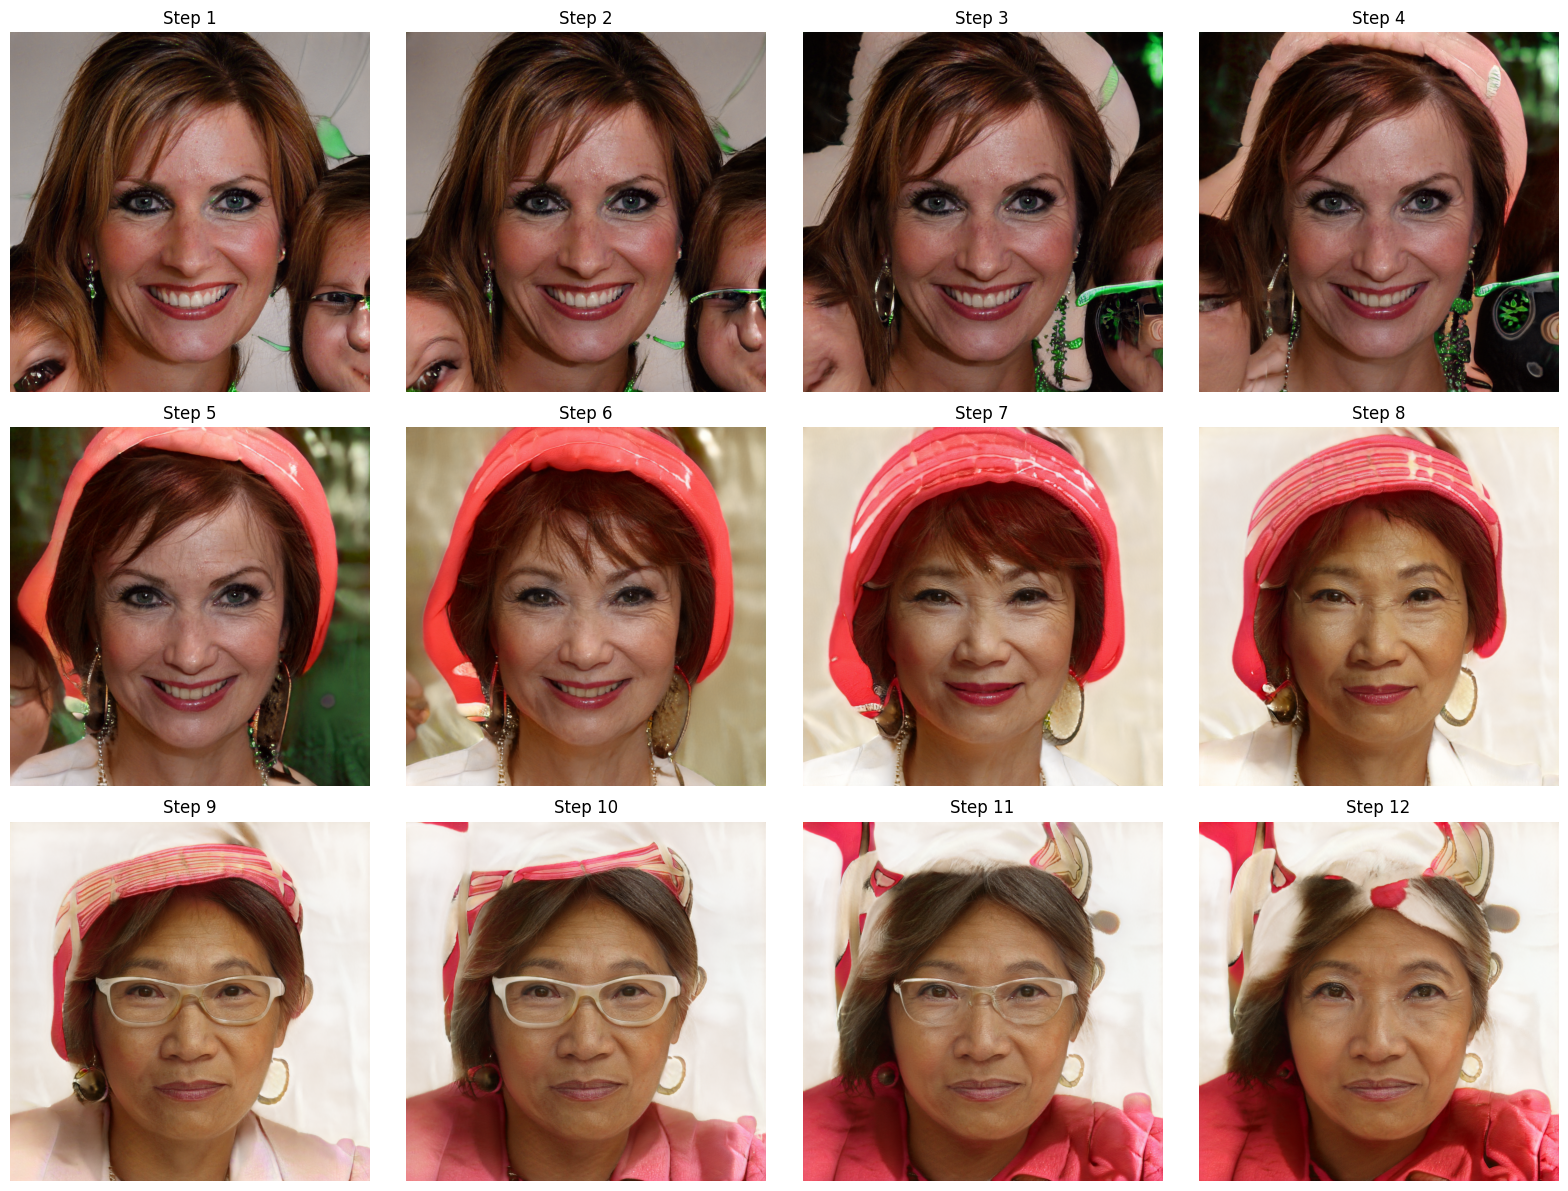

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for i, ax in enumerate(axes.flat):
    img = (interpolated_images[i].permute(1, 2, 0) + 1) / 2
    img = img.clamp(0, 1)

    ax.imshow(img.cpu())
    ax.set_title(f"Step {i+1}")
    ax.axis("off")

plt.tight_layout()
plt.show()

#6. Create the Image Strip

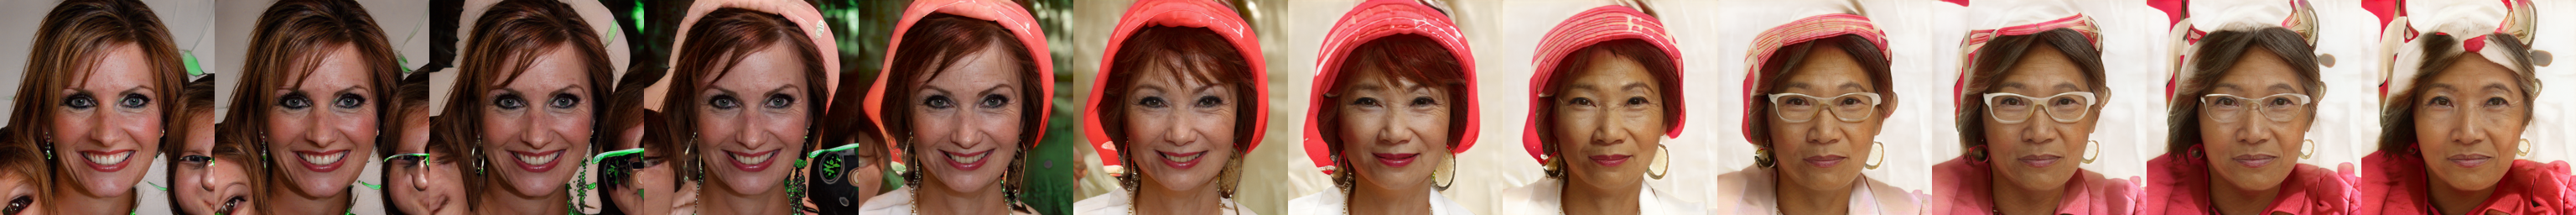

In [ ]:
from PIL import Image
import numpy as np

frames = []

for i in range(num_steps):
    img = (interpolated_images[i].permute(1, 2, 0) + 1) / 2
    img = img.clamp(0, 1)

    img = (img.cpu().numpy() * 255).astype(np.uint8)

    frames.append(Image.fromarray(img))

# Resize for a manageable submission image
small_frames = [img.resize((256, 256)) for img in frames]

# Create horizontal strip
strip = Image.new(
    "RGB",
    (256 * num_steps, 256)
)

for i, img in enumerate(small_frames):
    strip.paste(img, (i * 256, 0))

strip.save("stylegan2_interpolation_strip.png")

display(strip)

In [ ]:
# Copy Z1 so the original remains unchanged
Z_modified = Z1.clone()

# Change only two latent dimensions
Z_modified[0, 0] += 2.0
Z_modified[0, 1] -= 2.0

print("Original Z1 shape:", Z1.shape)
print("Modified Z shape:", Z_modified.shape)

Original Z1 shape: torch.Size([1, 512])
Modified Z shape: torch.Size([1, 512])


In [ ]:
with torch.no_grad():
    modified_img = G(
        Z_modified,
        None,
        noise_mode='const',
        force_fp32=True
    )

print("Modified image generated successfully.")

Modified image generated successfully.


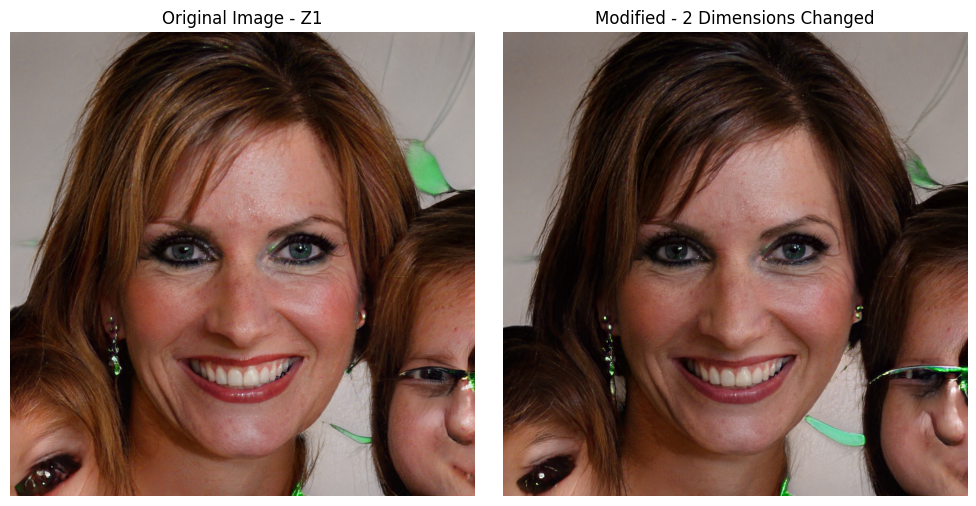

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Original image
original = (img1[0].permute(1, 2, 0) + 1) / 2
original = original.clamp(0, 1)

# Modified image
modified = (modified_img[0].permute(1, 2, 0) + 1) / 2
modified = modified.clamp(0, 1)

axes[0].imshow(original.cpu())
axes[0].set_title("Original Image - Z1")
axes[0].axis("off")

axes[1].imshow(modified.cpu())
axes[1].set_title("Modified - 2 Dimensions Changed")
axes[1].axis("off")

plt.tight_layout()
plt.show()

#7. Regenerate the original image

In [ ]:
noise_mode='const'

with torch.no_grad():
    regenerated_img = G(
        Z1,
        None,
        noise_mode='const',
        force_fp32=True
    )

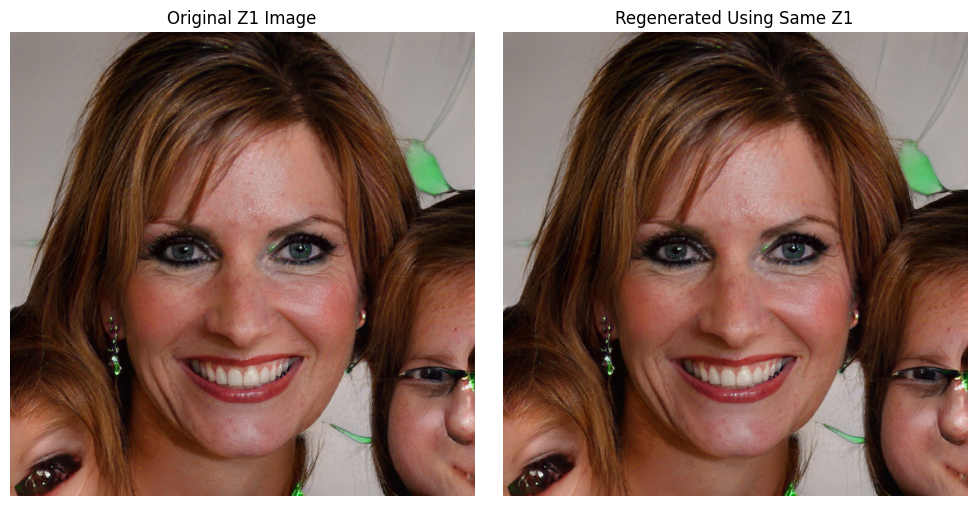

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

original = (img1[0].permute(1, 2, 0) + 1) / 2
regenerated = (regenerated_img[0].permute(1, 2, 0) + 1) / 2

original = original.clamp(0, 1)
regenerated = regenerated.clamp(0, 1)

axes[0].imshow(original.cpu())
axes[0].set_title("Original Z1 Image")
axes[0].axis("off")

axes[1].imshow(regenerated.cpu())
axes[1].set_title("Regenerated Using Same Z1")
axes[1].axis("off")

plt.tight_layout()
plt.show()

#Conclusion :

1. The interpolation gives a view of smooth transition of Z1 and Z2, rather than sudden change.
2. Changing two of latent vectors produce a visible difference in the generated image.
3. Regenaration of image using Z1  produce same kindoff output with a negligible variation.